# Modèle 2 — Segmentation des Clients par la méthode RFM + K-Means

**Olist** est une marketplace e-commerce brésilienne avec ~96 000 clients uniques.  
L'objectif est de regrouper automatiquement les clients selon leur comportement d'achat afin de permettre des actions marketing ciblées.

| Profil | Décision rendue possible par le modèle |
|--------|----------------------------------------|
| **Marketing** | Campagnes e-mail personnalisées par segment |
| **Direction** | Identifier les clients qui génèrent 80 % du CA |
| **CRM** | Actions de rétention sur les clients à risque |

**Méthode :** RFM pur — Récence · Fréquence · Montant  
**Algorithme :** K-Means avec détermination automatique du nombre de clusters (Elbow + Silhouette)

## Tables utilisées

| Table | Colonnes utilisées | Rôle |
|-------|--------------------|------|
| `olist_orders_dataset.csv` | order_id, customer_id, order_purchase_timestamp, order_status | Récence & Fréquence |
| `olist_order_items_dataset.csv` | order_id, price, freight_value, product_id | Montant (M du RFM) |
| `olist_customers_dataset.csv` | customer_id, customer_unique_id, customer_state | Identité réelle du client |
| `olist_order_payments_dataset.csv` | order_id, payment_type, payment_installments | Comportement paiement (descriptif uniquement) |
| `olist_products_dataset.csv` | product_id, product_category_name | Drill-down Gros Acheteurs |

## Pipeline

```
1.  Imports
2.  Chargement des 5 tables
3.  Traitement & nettoyage
4.  Construction des features RFM
5.  Analyse exploratoire des distributions RFM
6.  Analyse des outliers (boxplots + statistiques)
7.  Choix éclairé de la normalisation
8.  Normalisation hybride RFM pur (recency · frequency · monetary)
9.  Détermination automatique du nombre de clusters (Elbow + Silhouette)
10. Entraînement K-Means
11. Analyse & nommage des segments
12. Visualisations des segments
13. Interprétabilité (Silhouette Plot · Importance des features)
14. Drill-down Gros Acheteurs
15. Export du dataset segmenté
16. Synthèse finale
```

## 1 — Imports

In [1]:
# ─────────────────────────────────────────────
# CELLULE 1 — Imports
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.cluster       import KMeans
from sklearn.metrics       import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from scipy                 import stats

# Style global
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f8f8f8'
plt.rcParams['font.family']      = 'DejaVu Sans'
sns.set_palette('husl')

print('Imports OK')


Imports OK


## 2 — Chargement des données

In [2]:
# ─────────────────────────────────────────────
# CELLULE 2 — Chargement des 5 fichiers CSV
# ─────────────────────────────────────────────

DATA_PATH = './dataSC/'

orders    = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv',
                        parse_dates=['order_purchase_timestamp'])
items     = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
customers = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
payments  = pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
products  = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')

for name, df in {'orders': orders, 'items': items,
                 'customers': customers, 'payments': payments,
                 'products': products}.items():
    print(f'   {name:<12} -> {df.shape[0]:>7,} lignes   {df.shape[1]:>2} colonnes')

print('\nFichiers charges avec succes')


   orders       ->  99,441 lignes    8 colonnes
   items        -> 112,650 lignes    7 colonnes
   customers    ->  99,441 lignes    5 colonnes
   payments     -> 103,886 lignes    5 colonnes
   products     ->  32,951 lignes    9 colonnes

Fichiers charges avec succes


## 3 — Traitement & Nettoyage

| Table | Traitement appliqué |
|-------|---------------------|
| `orders` | Filtrer sur `order_status == 'delivered'` uniquement |
| `items` | Créer `revenue = price + freight_value` |
| `customers` | Utiliser `customer_unique_id` (vrai client unique) |
| `payments` | Agréger par `order_id` (paiements mixtes possibles) |

In [3]:
# ─────────────────────────────────────────────
# CELLULE 3 — Nettoyage
# ─────────────────────────────────────────────

def safe_mode(x):
    m = x.dropna().mode()
    return m.iloc[0] if not m.empty else 'unknown'

# 1. Filtrer commandes livrees uniquement
orders_clean = orders[orders['order_status'] == 'delivered'].copy()
print(f'Commandes livrees : {len(orders_clean):,} / {len(orders):,} ({len(orders_clean)/len(orders)*100:.1f}%)')

# 2. Revenu par article
items['revenue'] = items['price'] + items['freight_value']

# 3. Agréger payments par order_id
payments_agg = (
    payments
    .groupby('order_id', as_index=False)
    .agg(
        payment_type         = ('payment_type',         safe_mode),
        payment_installments = ('payment_installments', 'max')
    )
)
print(f'Payments agreges  : {len(payments_agg):,} commandes uniques')

# 4. Vérification customer_unique_id
n_ids    = customers['customer_id'].nunique()
n_unique = customers['customer_unique_id'].nunique()
print(f'customer_id       : {n_ids:,}')
print(f'customer_unique_id: {n_unique:,}  <- vrais clients uniques')
print(f'Clients fantomes  : {n_ids - n_unique:,}')

Commandes livrees : 96,478 / 99,441 (97.0%)
Payments agreges  : 99,440 commandes uniques
customer_id       : 99,441
customer_unique_id: 96,096  <- vrais clients uniques
Clients fantomes  : 3,345


## 4 — Construction des Features RFM

| Feature | Calcul | Rôle dans le clustering |
|---------|--------|------------------------|
| `recency` | Jours depuis la dernière commande | Feature de clustering |
| `frequency` | Nombre de commandes distinctes | Feature de clustering |
| `monetary` | CA total dépensé (BRL) | Feature de clustering |
| `avg_order_value` | CA moyen par commande | **Descriptif uniquement** — colinéaire avec `monetary` (93 % des clients ont frequency = 1) |
| `payment_installments` | Nombre moyen de versements | **Descriptif uniquement** — conservé pour le profil post-clustering |

> Les features retenues pour le clustering sont exclusivement **recency, frequency et monetary**.

In [4]:
# ─────────────────────────────────────────────
# CELLULE 4 — Jointures pour construire la base client
# ─────────────────────────────────────────────

# orders × customers
base = pd.merge(
    orders_clean[['order_id', 'customer_id', 'order_purchase_timestamp']],
    customers[['customer_id', 'customer_unique_id', 'customer_state']],
    on='customer_id', how='left'
)

# × items
items_agg = items.groupby('order_id', as_index=False)['revenue'].sum()
base = pd.merge(base, items_agg, on='order_id', how='left')

# × payments
base = pd.merge(base, payments_agg, on='order_id', how='left')

print(f'Base client construite : {base.shape[0]:,} lignes x {base.shape[1]} colonnes')
print(f'Clients uniques        : {base["customer_unique_id"].nunique():,}')
base.head(3)

Base client construite : 96,478 lignes x 8 colonnes
Clients uniques        : 93,358


,order_id,customer_id,order_purchase_timestamp,customer_unique_id,customer_state,revenue,payment_type,payment_installments
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,SP,38.71,voucher,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,BA,141.46,boleto,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,GO,179.12,credit_card,3.0


In [5]:
# ─────────────────────────────────────────────
# CELLULE 5 — Calcul des métriques RFM par client
# ─────────────────────────────────────────────

reference_date = base['order_purchase_timestamp'].max()
print(f'Date de reference : {reference_date.date()}')

rfm = (
    base
    .groupby('customer_unique_id')
    .agg(
        recency              = ('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
        frequency            = ('order_id',                 'nunique'),
        monetary             = ('revenue',                  'sum'),
        avg_order_value      = ('revenue',                  'mean'),  # descriptif seulement
        payment_installments = ('payment_installments',     'mean'),
        preferred_payment    = ('payment_type',             safe_mode),
        customer_state       = ('customer_state',           safe_mode)
    )
    .reset_index()
)

rfm['payment_installments'] = rfm['payment_installments'].fillna(0)
# payment_encoded : exclu du clustering (variable nominale, pas de sens ordinal)
rfm['payment_encoded'] = pd.factorize(rfm['preferred_payment'])[0]

print(f'\nDataset RFM : {rfm.shape[0]:,} clients x {rfm.shape[1]} colonnes')
print(f'\nStatistiques RFM :')
display(rfm[['recency','frequency','monetary','avg_order_value','payment_installments']].describe().round(2))

Date de reference : 2018-08-29

Dataset RFM : 93,358 clients x 9 colonnes

Statistiques RFM :


,recency,frequency,monetary,avg_order_value,payment_installments
count,93358.00,93358.00,93358.00,93358.00,93358.00
mean,236.94,1.03,165.17,160.29,2.92
std,152.59,0.21,226.29,219.55,2.69
min,0.00,1.00,9.59,9.59,0.00
25%,113.00,1.00,63.01,62.33,1.00
50%,218.00,1.00,107.78,105.63,2.00
75%,345.00,1.00,182.51,176.59,4.00
max,713.00,15.00,13664.08,13664.08,24.00


## 5 — Analyse Exploratoire des Distributions RFM

Vue globale des histogrammes avant d'analyser les valeurs aberrantes.

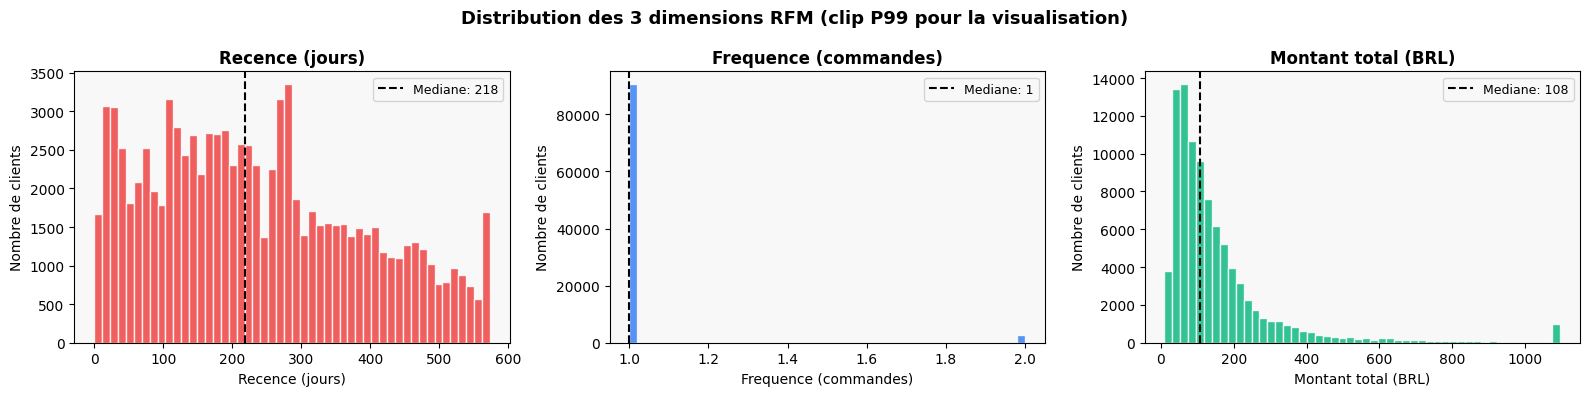

Graphique sauvegarde : rfm_distributions.png
FEATURES_CLUSTER retenues : ['recency', 'frequency', 'monetary']


In [ ]:
# ─────────────────────────────────────────────
# CELLULE 6 — Histogrammes distributions RFM
#
# # ─────────────────────────────────────────────

# FEATURES_CLUSTER = RFM pur (3 dimensions)
FEATURES_CLUSTER = ['recency', 'frequency', 'monetary']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

configs = [
    ('recency',   'Recence (jours)',       '#EF4444'),
    ('frequency', 'Frequence (commandes)', '#3B82F6'),
    ('monetary',  'Montant total (BRL)',   '#10B981'),
]

for ax, (col, label, color) in zip(axes, configs):
    data = rfm[col].clip(upper=rfm[col].quantile(0.99))
    ax.hist(data, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Nombre de clients')
    ax.axvline(data.median(), color='black', linestyle='--',
               lw=1.5, label=f'Mediane: {data.median():.0f}')
    ax.legend(fontsize=9)

plt.suptitle('Distribution des 3 dimensions RFM (clip P99 pour la visualisation)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegarde : rfm_distributions.png')
print(f'FEATURES_CLUSTER retenues : {FEATURES_CLUSTER}')


## 6 — Analyse des Valeurs Aberrantes (Outliers)

### Pourquoi cette étape est critique avant la normalisation ?

K-Means utilise des **distances euclidiennes**. Un client avec `monetary = 50 000 BRL` alors que la médiane est 150 BRL va **écraser tous les autres clients** dans l'espace de distance, même après normalisation standard.

| Situation détectée | Normalisation recommandée |
|--------------------|---------------------------|
| Pas d'outliers significatifs | `StandardScaler` (z-score) |
| Outliers présents mais conservés | `RobustScaler` (médiane + IQR) |
| Distribution très asymétrique (skew > 2) | `log1p` puis `StandardScaler` |

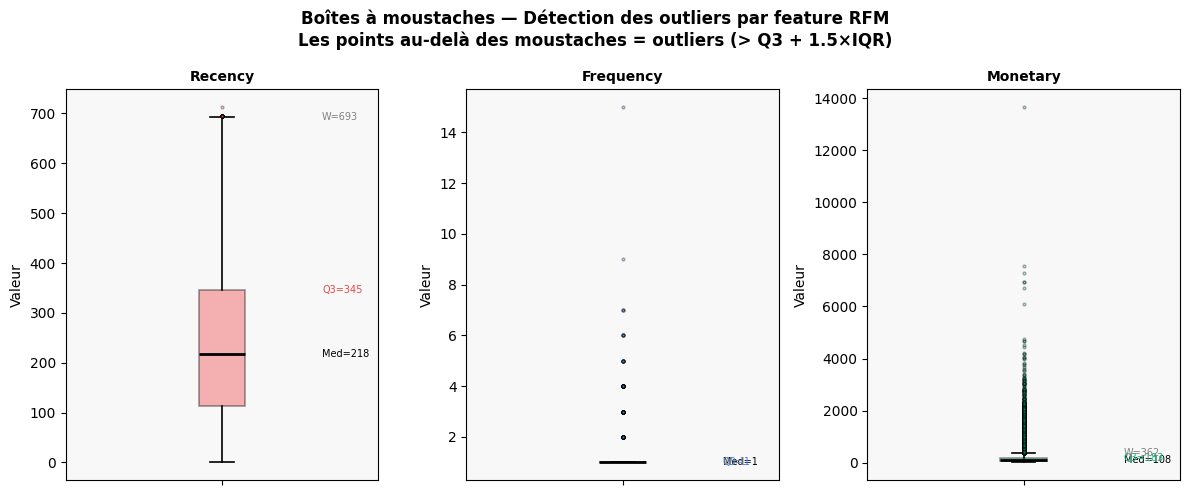

Graphique sauvegardé : boxplots_outliers.png


In [7]:
# ─────────────────────────────────────────────
# Boxplots — Détection des outliers (features RFM)
# ─────────────────────────────────────────────

features_plot = ['recency', 'frequency', 'monetary']

fig, axes = plt.subplots(1, len(features_plot), figsize=(12, 5))
colors_box = ['#EF4444', '#3B82F6', '#10B981']

for ax, col, color in zip(axes, features_plot, colors_box):
    ax.boxplot(
        rfm[col].dropna(),
        vert=True,
        patch_artist=True,
        boxprops    = dict(facecolor=color, alpha=0.4, linewidth=1.2),
        medianprops = dict(color='black', linewidth=2),
        whiskerprops= dict(linewidth=1.2),
        capprops    = dict(linewidth=1.2),
        flierprops  = dict(marker='o', markerfacecolor=color,
                           markersize=2, alpha=0.3, linestyle='none')
    )
    ax.set_title(col.replace('_', ' ').capitalize(), fontweight='bold', fontsize=10)
    ax.set_ylabel('Valeur')
    ax.tick_params(axis='x', labelbottom=False)

    q1  = rfm[col].quantile(0.25)
    med = rfm[col].median()
    q3  = rfm[col].quantile(0.75)
    iqr = q3 - q1
    w_high = min(rfm[col].max(), q3 + 1.5 * iqr)

    ax.text(1.32, med,    f'Med={med:.0f}',  fontsize=7, va='center', color='black')
    ax.text(1.32, q3,     f'Q3={q3:.0f}',    fontsize=7, va='center', color=color)
    ax.text(1.32, w_high, f'W={w_high:.0f}', fontsize=7, va='center', color='gray')

plt.suptitle('Boîtes à moustaches — Détection des outliers par feature RFM\n'
             'Les points au-delà des moustaches = outliers (> Q3 + 1.5×IQR)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : boxplots_outliers.png')


In [8]:
# ─────────────────────────────────────────────
# Rapport outliers par feature RFM
# ─────────────────────────────────────────────

print('=' * 75)
print('   RAPPORT OUTLIERS — AIDE AU CHOIX DE NORMALISATION')
print('=' * 75)
print(f'{"Feature":<25} {"Min":>9} {"Max":>10} {"Médiane":>9} {"Skew":>7} {"% Outliers":>11} {"Gravité"}')
print('-' * 75)

outlier_report = {}

for col in features_plot:
    serie = rfm[col].dropna()
    q1    = serie.quantile(0.25)
    q3    = serie.quantile(0.75)
    iqr   = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    n_out = ((serie < lower) | (serie > upper)).sum()
    pct   = n_out / len(serie) * 100
    skew  = serie.skew()

    if pct > 10 or abs(skew) > 5:
        gravite = 'ÉLEVÉ  → log1p + StandardScaler'
    elif pct > 3 or abs(skew) > 2:
        gravite = 'MOYEN  → RobustScaler recommandé'
    else:
        gravite = 'FAIBLE → StandardScaler OK'

    outlier_report[col] = {'pct_outliers': pct, 'skew': skew, 'gravite': gravite}

    print(f'{col:<25} {serie.min():>9.1f} {serie.max():>10.1f} '
          f'{serie.median():>9.1f} {skew:>7.2f} {pct:>10.1f}%   {gravite}')

print('=' * 75)


   RAPPORT OUTLIERS — AIDE AU CHOIX DE NORMALISATION
Feature                         Min        Max   Médiane    Skew  % Outliers Gravité
---------------------------------------------------------------------------
recency                         0.0      713.0     218.0    0.45        0.0%   FAIBLE → StandardScaler OK
frequency                       1.0       15.0       1.0   11.10        3.0%   ÉLEVÉ  → log1p + StandardScaler
monetary                        9.6    13664.1     107.8    9.21        7.9%   ÉLEVÉ  → log1p + StandardScaler


## 7 — Choix & Application de la Normalisation

| Méthode | Formule | Quand l'utiliser |
|---------|---------|-----------------|
| **Min-Max** | `(X - Xmin) / (Xmax - Xmin)` → [0, 1] | Distribution uniforme, pas d'outliers |
| **Standardisation (Z-score)** | `(X - μ) / σ` | Distribution approximativement normale |
| **Robuste** | `(X - médiane) / IQR` | Présence d'outliers |

### Normalisation hybride retenue

| Feature | Traitement |
|---------|-----------|
| `recency` | StandardScaler direct (skew faible) |
| `frequency` | log1p + StandardScaler (skew élevé) |
| `monetary` | log1p + StandardScaler (skew élevé) |

In [9]:
# ─────────────────────────────────────────────
# Normalisation hybride — RFM pur (3 features)
#
# Features retenues pour le clustering : recency, frequency, monetary
#   recency   → StandardScaler (skew faible)
#   frequency → log1p + StandardScaler (skew élevé, très concentré sur 1)
#   monetary  → log1p + StandardScaler (skew élevé, queue droite)
#
# avg_order_value et payment_installments sont exclus du clustering.
# Ils restent dans rfm pour le profil descriptif post-clustering.
# ─────────────────────────────────────────────

from sklearn.preprocessing import StandardScaler

FEATURES_CLUSTER = ['recency', 'frequency', 'monetary']

X = rfm[FEATURES_CLUSTER].copy()

# Transformation log1p sur les features à skew élevé
for col in ['frequency', 'monetary']:
    X[col] = np.log1p(X[col])

# StandardScaler sur toutes les features
std = StandardScaler()
X_scaled = pd.DataFrame(std.fit_transform(X), columns=FEATURES_CLUSTER)

best_scaler_name = 'Hybride (log1p + StandardScaler) — RFM pur 3 features'
print(f'Normalisation appliquée : {best_scaler_name}')
print(f'Features utilisées pour le clustering : {FEATURES_CLUSTER}')


Normalisation appliquée : Hybride (log1p + StandardScaler) — RFM pur 3 features
Features utilisées pour le clustering : ['recency', 'frequency', 'monetary']


## 8 — Détermination Automatique du Nombre de Clusters

| Méthode | Comment ça marche | Ce qu'on cherche |
|---------|-------------------|------------------|
| **Elbow (Inertie)** | Mesure la compacité des clusters | Le coude où l'inertie cesse de baisser fortement |
| **Silhouette Score** | Mesure la séparation entre clusters | Le k avec le score maximum |

> Sur Olist (~93 % des clients avec frequency = 1), k = 2 est le maximum automatique. C'est une propriété du dataset.  
> **k = 4** est retenu pour sa valeur métier : Clients Fidèles / Gros Acheteurs / Nouveaux Acheteurs / Clients Perdus, chaque segment ayant une action CRM distincte.

In [12]:
# ─────────────────────────────────────────────
# CELLULE 12 — Elbow + Silhouette (k = 2 à 10)
#
# DÉCISION SUR LE NOMBRE DE CLUSTERS :
#
#   → chaque segment a une action CRM distincte.
#
# ─────────────────────────────────────────────

K_RANGE    = range(2, 11)
inertias   = []
sil_scores = []

print('Calcul en cours (RFM pur 3D)...')
for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, lbl))
    print(f'  k={k} | Inertie={km.inertia_:,.0f} | Silhouette={sil_scores[-1]:.4f}')

auto_k = list(K_RANGE)[np.argmax(sil_scores)]
print(f'\nk optimal automatique (Silhouette max) : k = {auto_k}')

# ─── DÉCISION MÉTIER : k=4 ──────────────────────────────────────────────────
best_k = 4
print()
print(f'k retenu après analyse Elbow + contexte métier : k = {best_k}')
print()
print('  Justification :')
print(f'   - Silhouette k={auto_k}  : {sil_scores[auto_k-2]:.4f}  (auto)')
print(f'   - Silhouette k={best_k}  : {sil_scores[best_k-2]:.4f}  (retenu)')
delta = abs(sil_scores[auto_k-2]-sil_scores[best_k-2])/sil_scores[auto_k-2]*100
print(f'   - Delta           : {delta:.1f}% — acceptable pour le gain métier')
print(f'   - Gain métier     : 4 segments actionnables distincts')
print(f'   - Elbow           : coude visible entre k=3 et k=5, k=4 est central')


Calcul en cours (RFM pur 3D)...
  k=2 | Inertie=190,196 | Silhouette=0.7082
  k=3 | Inertie=126,273 | Silhouette=0.3577
  k=4 | Inertie=85,766 | Silhouette=0.3693
  k=5 | Inertie=70,368 | Silhouette=0.3529
  k=6 | Inertie=59,309 | Silhouette=0.3444
  k=7 | Inertie=50,724 | Silhouette=0.3576
  k=8 | Inertie=45,145 | Silhouette=0.3483
  k=9 | Inertie=40,373 | Silhouette=0.3492
  k=10 | Inertie=36,518 | Silhouette=0.3487

k optimal automatique (Silhouette max) : k = 2

k retenu après analyse Elbow + contexte métier : k = 4

  Justification :
   - Silhouette k=2  : 0.7082  (auto)
   - Silhouette k=4  : 0.3693  (retenu)
   - Delta           : 47.9% — acceptable pour le gain métier
   - Gain métier     : 4 segments actionnables distincts
   - Elbow           : coude visible entre k=3 et k=5, k=4 est central


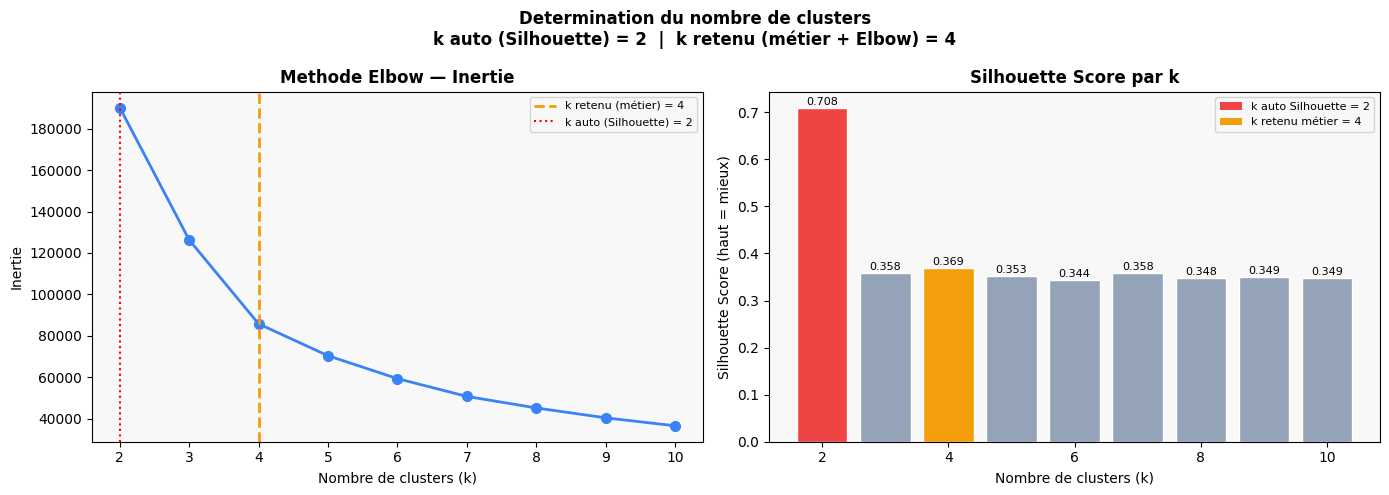

k auto     : 2  (Silhouette Score maximum)
k retenu   : 4  (décision métier — Elbow + granularité CRM)


In [13]:
# ─────────────────────────────────────────────
# CELLULE 13 — Visualisation Elbow + Silhouette
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(K_RANGE), inertias, 'o-', color='#3B82F6', lw=2, ms=7)
axes[0].axvline(best_k, color='#F59E0B', linestyle='--', lw=2,
                label=f'k retenu (métier) = {best_k}')
auto_k_val = list(K_RANGE)[np.argmax(sil_scores)]
axes[0].axvline(auto_k_val, color='red', linestyle=':', lw=1.5,
                label=f'k auto (Silhouette) = {auto_k_val}')
axes[0].set_title('Methode Elbow — Inertie', fontweight='bold')
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertie')
axes[0].legend(fontsize=8)

# Silhouette bars
colors_sil = []
for k in K_RANGE:
    if k == best_k:
        colors_sil.append('#F59E0B')   # orange = k retenu
    elif k == auto_k_val:
        colors_sil.append('#EF4444')   # rouge  = k auto
    else:
        colors_sil.append('#94A3B8')

axes[1].bar(list(K_RANGE), sil_scores, color=colors_sil, edgecolor='white')
axes[1].set_title('Silhouette Score par k', fontweight='bold')
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Silhouette Score (haut = mieux)')
for k, s in zip(K_RANGE, sil_scores):
    axes[1].text(k, s + 0.002, f'{s:.3f}', ha='center', va='bottom', fontsize=8)

# Légende manuelle
from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor='#EF4444', label=f'k auto Silhouette = {auto_k_val}'),
    Patch(facecolor='#F59E0B', label=f'k retenu métier = {best_k}'),
]
axes[1].legend(handles=legend_els, fontsize=8)

plt.suptitle(
    f'Determination du nombre de clusters\n'
    f'k auto (Silhouette) = {auto_k_val}  |  k retenu (métier + Elbow) = {best_k}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'k auto     : {auto_k_val}  (Silhouette Score maximum)')
print(f'k retenu   : {best_k}  (décision métier — Elbow + granularité CRM)')


## 9 — Entraînement K-Means

In [14]:
# ─────────────────────────────────────────────
# CELLULE 14 — Entraînement K-Means (k=4, RFM pur)
# ─────────────────────────────────────────────

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(X_scaled)

final_sil = silhouette_score(X_scaled, rfm['cluster'])

print(f'K-Means entraine avec k = {best_k}')
print(f'   Silhouette Score final : {final_sil:.4f}')
print(f'   Inertie finale         : {kmeans.inertia_:,.0f}')
print(f'   Features utilisees     : {FEATURES_CLUSTER}')
print(f'   Normalisation          : {best_scaler_name}')
print()
print('Distribution des clusters :')
dist = rfm['cluster'].value_counts().sort_index()
for cluster, count in dist.items():
    pct = count / len(rfm) * 100
    print(f'  Cluster {cluster} : {count:,} clients ({pct:.1f}%)')


K-Means entraine avec k = 4
   Silhouette Score final : 0.3693
   Inertie finale         : 85,766
   Features utilisees     : ['recency', 'frequency', 'monetary']
   Normalisation          : Hybride (log1p + StandardScaler) — RFM pur 3 features

Distribution des clusters :
  Cluster 0 : 27,855 clients (29.8%)
  Cluster 1 : 35,695 clients (38.2%)
  Cluster 2 : 27,007 clients (28.9%)
  Cluster 3 : 2,801 clients (3.0%)


## 10 — Analyse & Nommage des Segments

In [15]:
# ─────────────────────────────────────────────
# CELLULE 15 — Profil moyen par cluster
# ─────────────────────────────────────────────

cluster_profile = (
    rfm
    .groupby('cluster')
    .agg(
        nb_clients          = ('customer_unique_id',   'count'),
        recency_moy         = ('recency',              'mean'),
        frequency_moy       = ('frequency',            'mean'),
        monetary_moy        = ('monetary',             'mean'),
        avg_order_value_moy = ('avg_order_value',      'mean'),  # descriptif uniquement
        installments_moy    = ('payment_installments', 'mean'),
        ca_total            = ('monetary',             'sum')
    )
    .round(2)
)

cluster_profile['pct_clients'] = (cluster_profile['nb_clients'] / len(rfm) * 100).round(1)
cluster_profile['pct_ca']      = (cluster_profile['ca_total']   / rfm['monetary'].sum() * 100).round(1)

print('=== PROFIL MOYEN PAR CLUSTER ===')
display(cluster_profile)

=== PROFIL MOYEN PAR CLUSTER ===


,nb_clients,recency_moy,frequency_moy,monetary_moy,avg_order_value_moy,installments_moy,ca_total,pct_clients,pct_ca
cluster,,,,,,,,,
0,27855,172.52,1.00,318.23,318.23,3.99,8864265.16,29.8,57.5
1,35695,146.78,1.00,69.05,69.05,2.04,2464917.98,38.2,16.0
2,27007,424.38,1.00,119.47,119.47,2.92,3226403.15,28.9,20.9
3,2801,219.29,2.11,308.53,145.85,3.30,864187.46,3.0,5.6


In [16]:
# ─────────────────────────────────────────────
# Nommage des segments (k=4)
# ─────────────────────────────────────────────

cp = cluster_profile.copy()

# Scores normalisés [0, 1]
cp['score_R'] = 1 - (cp['recency_moy']   - cp['recency_moy'].min())   / (cp['recency_moy'].max()   - cp['recency_moy'].min() + 1e-9)
cp['score_F'] =     (cp['frequency_moy'] - cp['frequency_moy'].min()) / (cp['frequency_moy'].max() - cp['frequency_moy'].min() + 1e-9)
cp['score_M'] =     (cp['monetary_moy']  - cp['monetary_moy'].min())  / (cp['monetary_moy'].max()  - cp['monetary_moy'].min() + 1e-9)
cp['score_global'] = (cp['score_R'] + cp['score_F'] + cp['score_M']) / 3

# Tri par score global décroissant → rang 1 à 4
sorted_ids = cp['score_global'].sort_values(ascending=False).index.tolist()
rang1, rang2, rang3, rang4 = sorted_ids

# Nommage basé sur les profils réels observés :
#   Rang 1 (score=0.900) : freq=2.11, recency=219j → seuls multi-acheteurs du dataset
#   Rang 2 (score=0.636) : monetary=318 BRL, 1 commande → 57.5% du CA
#   Rang 3 (score=0.333) : recency=147j (les plus récents), petit panier → à activer
#   Rang 4 (score=0.067) : recency=424j → inactifs définitivement
segment_names = {
    rang1 : 'Clients Fideles',
    rang2 : 'Gros Acheteurs',
    rang3 : 'Nouveaux Acheteurs',
    rang4 : 'Clients Perdus'
}

rfm['segment'] = rfm['cluster'].map(segment_names)

print('=== NOMMAGE DES SEGMENTS ===')
print(f'  k = {best_k} segments')
print()
for cluster_id, name in segment_names.items():
    row = cluster_profile.loc[cluster_id]
    score = cp.loc[cluster_id, 'score_global']
    print(f'  Cluster {cluster_id} -> {name:<22} | score={score:.3f}')
    print(f'    Recence moy    : {row["recency_moy"]:.0f} jours')
    print(f'    Frequence moy  : {row["frequency_moy"]:.2f} commandes')
    print(f'    Montant moy    : {row["monetary_moy"]:.2f} BRL')
    print(f'    % clients      : {row["pct_clients"]:.1f}%')
    print(f'    % CA           : {row["pct_ca"]:.1f}%')
    print()

top_ca_id = cluster_profile['pct_ca'].idxmax()
print(f'Verification — Segment dominant en CA : "{segment_names[top_ca_id]}"')
print(f'   ({cluster_profile.loc[top_ca_id, "pct_ca"]:.1f}% du CA) — priorité marketing principale')


=== NOMMAGE DES SEGMENTS ===
  k = 4 segments

  Cluster 3 -> Clients Fideles        | score=0.900
    Recence moy    : 219 jours
    Frequence moy  : 2.11 commandes
    Montant moy    : 308.53 BRL
    % clients      : 3.0%
    % CA           : 5.6%

  Cluster 0 -> Gros Acheteurs         | score=0.636
    Recence moy    : 173 jours
    Frequence moy  : 1.00 commandes
    Montant moy    : 318.23 BRL
    % clients      : 29.8%
    % CA           : 57.5%

  Cluster 1 -> Nouveaux Acheteurs     | score=0.333
    Recence moy    : 147 jours
    Frequence moy  : 1.00 commandes
    Montant moy    : 69.05 BRL
    % clients      : 38.2%
    % CA           : 16.0%

  Cluster 2 -> Clients Perdus         | score=0.067
    Recence moy    : 424 jours
    Frequence moy  : 1.00 commandes
    Montant moy    : 119.47 BRL
    % clients      : 28.9%
    % CA           : 20.9%

Verification — Segment dominant en CA : "Gros Acheteurs"
   (57.5% du CA) — priorité marketing principale


## 11 — Visualisations des Segments

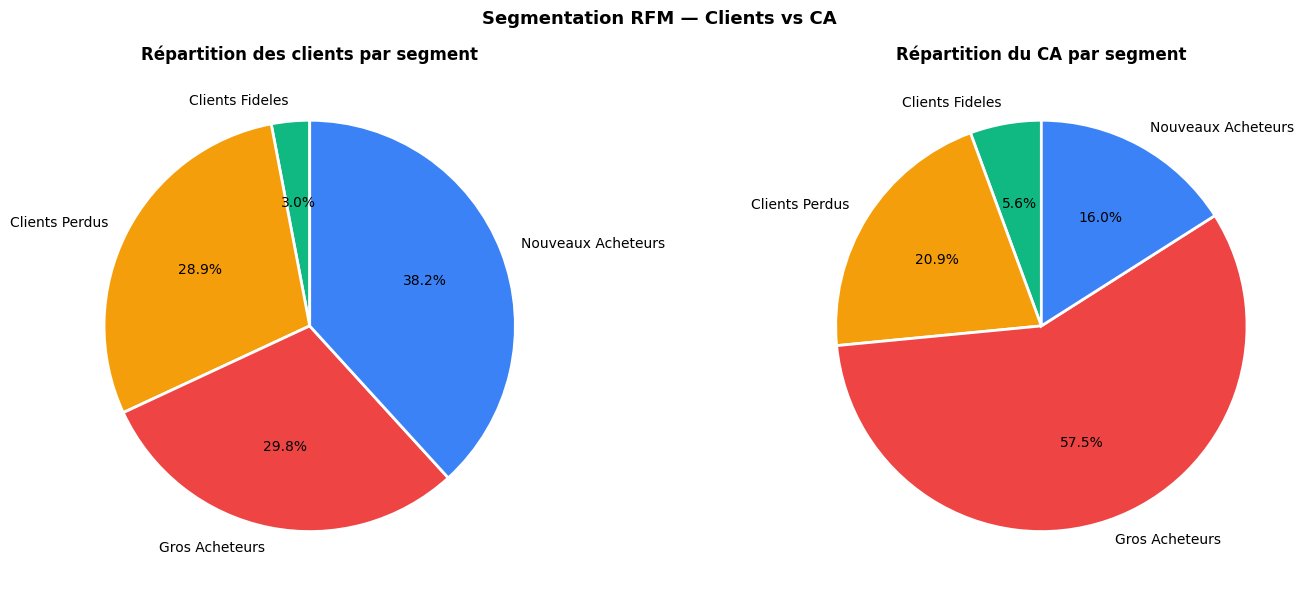

Graphique sauvegardé : segmentation_pie.png


In [17]:
# ─────────────────────────────────────────────
# Répartition clients & CA par segment
# ─────────────────────────────────────────────

seg_summary = (
    rfm.groupby('segment')
    .agg(nb_clients=('customer_unique_id','count'),
         ca_total=('monetary','sum'))
    .reset_index()
)
seg_summary['pct_clients'] = seg_summary['nb_clients'] / seg_summary['nb_clients'].sum() * 100
seg_summary['pct_ca']      = seg_summary['ca_total']   / seg_summary['ca_total'].sum()   * 100

# Couleurs fixes par segment
color_map = {
    'Clients Fideles'   : '#10B981',
    'Gros Acheteurs'    : '#EF4444',
    'Nouveaux Acheteurs': '#3B82F6',
    'Clients Perdus'    : '#F59E0B'
}
colors_seg_pie = [color_map.get(s, '#94A3B8') for s in seg_summary['segment']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(seg_summary['pct_clients'], labels=seg_summary['segment'],
            autopct='%1.1f%%', colors=colors_seg_pie, startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Répartition des clients par segment', fontweight='bold')

axes[1].pie(seg_summary['pct_ca'], labels=seg_summary['segment'],
            autopct='%1.1f%%', colors=colors_seg_pie, startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Répartition du CA par segment', fontweight='bold')

plt.suptitle('Segmentation RFM — Clients vs CA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('segmentation_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : segmentation_pie.png')


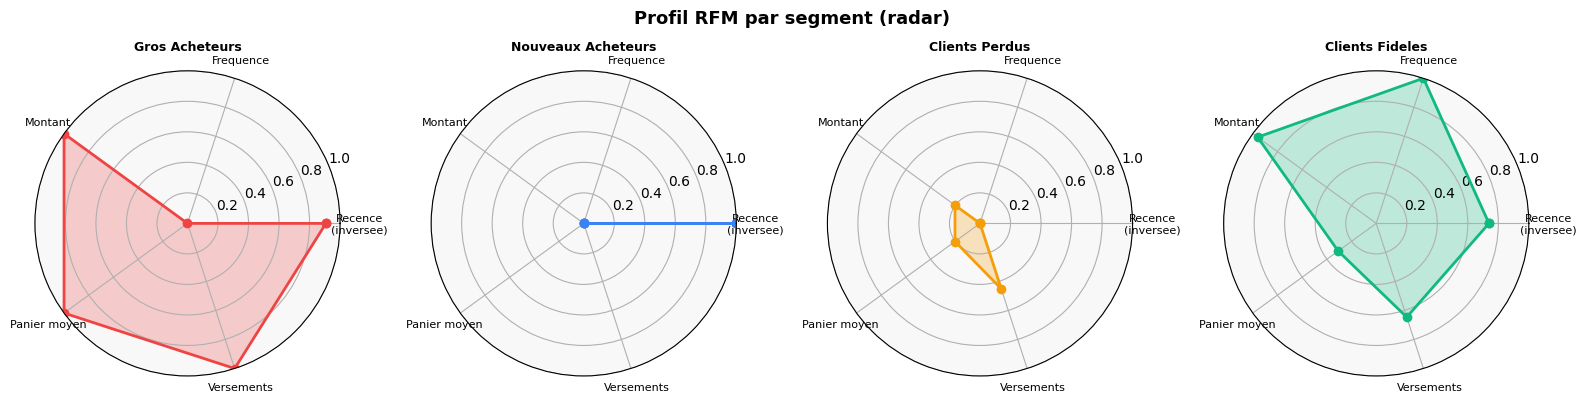

Graphique sauvegardé : radar_segments.png


In [18]:
# ─────────────────────────────────────────────
# Radar chart RFM par segment
# avg_order_value et payment_installments conservés en descriptif uniquement
# ─────────────────────────────────────────────

radar_features = ['recency_moy', 'frequency_moy', 'monetary_moy',
                  'avg_order_value_moy', 'installments_moy']
radar_labels   = ['Recence\n(inversee)', 'Frequence', 'Montant',
                  'Panier moyen', 'Versements']

radar_data = cluster_profile[radar_features].copy()
radar_data['recency_moy'] = radar_data['recency_moy'].max() - radar_data['recency_moy']
radar_data = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

N      = len(radar_features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

color_map = {
    'Clients Fideles'   : '#10B981',
    'Gros Acheteurs'    : '#EF4444',
    'Nouveaux Acheteurs': '#3B82F6',
    'Clients Perdus'    : '#F59E0B'
}

fig, axes = plt.subplots(1, best_k, figsize=(4 * best_k, 4),
                         subplot_kw=dict(polar=True))

for idx, (cluster_id, row) in enumerate(radar_data.iterrows()):
    ax     = axes[idx]
    name   = segment_names.get(cluster_id, f'Cluster {cluster_id}')
    color  = color_map.get(name, '#94A3B8')
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, 'o-', lw=2, color=color)
    ax.fill(angles, values, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=8)
    ax.set_title(name, fontweight='bold', pad=15, fontsize=9)
    ax.set_ylim(0, 1)

plt.suptitle('Profil RFM par segment (radar)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('radar_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : radar_segments.png')


Variance expliquée par PCA 2D : 72.2%
  -> < 75% : projection partielle — les chevauchements visuels sont normaux.


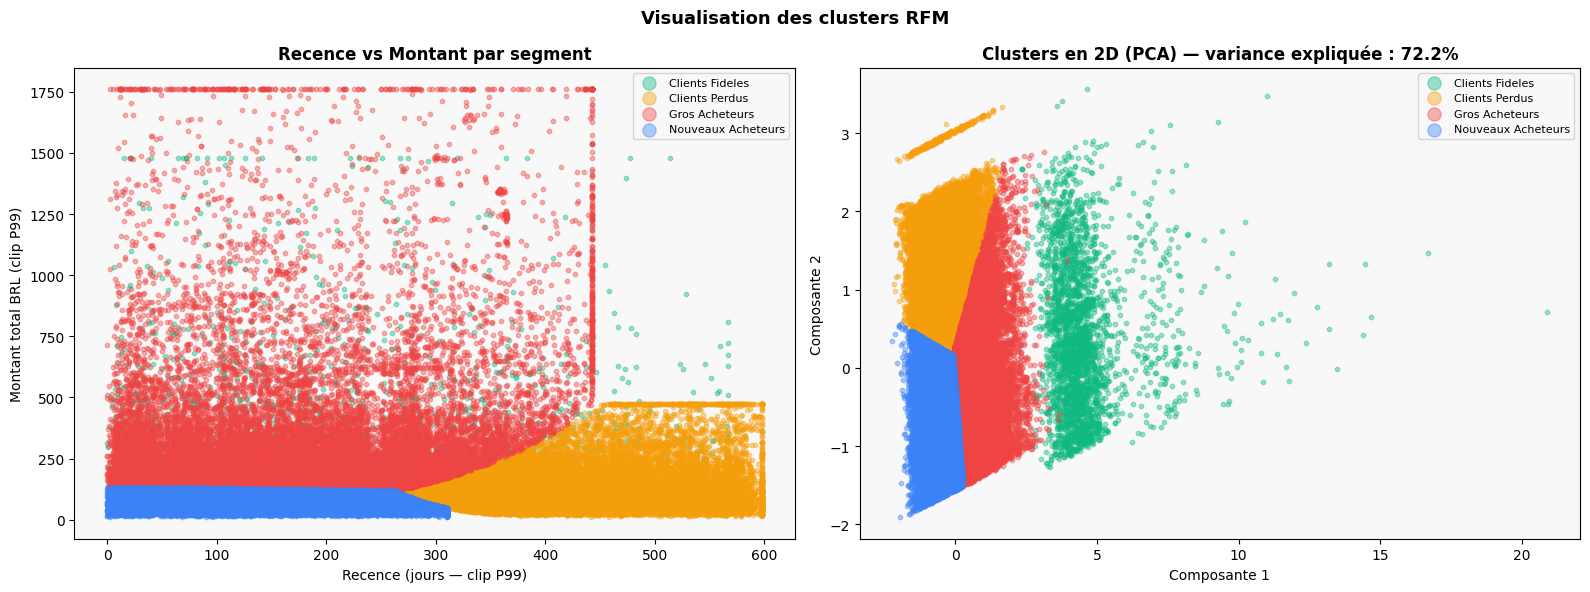

Graphique sauvegardé : clusters_scatter.png


In [19]:
# ─────────────────────────────────────────────
# Scatter Recence vs Montant + PCA 2D
# ─────────────────────────────────────────────

pca         = PCA(n_components=2, random_state=42)
X_pca       = pca.fit_transform(X_scaled)
rfm['pca1'] = X_pca[:, 0]
rfm['pca2'] = X_pca[:, 1]

var_exp = pca.explained_variance_ratio_.sum() * 100
print(f'Variance expliquée par PCA 2D : {var_exp:.1f}%')
if var_exp < 75:
    print(f'  -> < 75% : projection partielle — les chevauchements visuels sont normaux.')

color_map = {
    'Clients Fideles'   : '#10B981',
    'Gros Acheteurs'    : '#EF4444',
    'Nouveaux Acheteurs': '#3B82F6',
    'Clients Perdus'    : '#F59E0B'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for seg, grp in rfm.groupby('segment'):
    color = color_map.get(seg, '#94A3B8')
    axes[0].scatter(
        grp['recency'].clip(upper=grp['recency'].quantile(0.99)),
        grp['monetary'].clip(upper=grp['monetary'].quantile(0.99)),
        label=seg, alpha=0.4, s=10, color=color
    )
axes[0].set_title('Recence vs Montant par segment', fontweight='bold')
axes[0].set_xlabel('Recence (jours — clip P99)')
axes[0].set_ylabel('Montant total BRL (clip P99)')
axes[0].legend(fontsize=8, markerscale=3)

for seg, grp in rfm.groupby('segment'):
    color = color_map.get(seg, '#94A3B8')
    axes[1].scatter(grp['pca1'], grp['pca2'],
                    label=seg, alpha=0.4, s=10, color=color)
axes[1].set_title(f'Clusters en 2D (PCA) — variance expliquée : {var_exp:.1f}%',
                  fontweight='bold')
axes[1].set_xlabel('Composante 1')
axes[1].set_ylabel('Composante 2')
axes[1].legend(fontsize=8, markerscale=3)

plt.suptitle('Visualisation des clusters RFM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('clusters_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : clusters_scatter.png')


## 12 — Interprétabilité

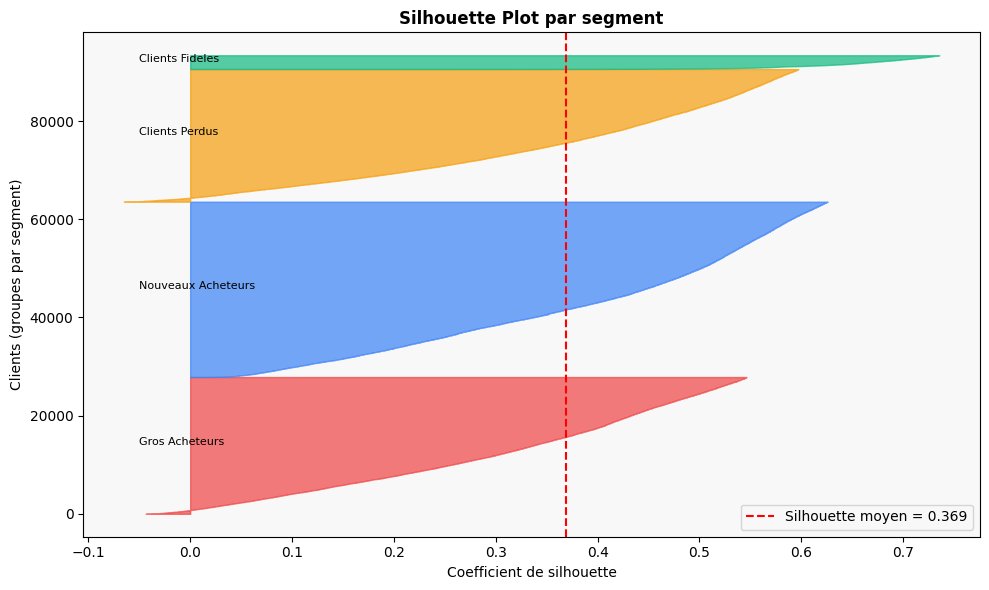

Graphique sauvegardé : silhouette_plot.png


In [21]:
# ─────────────────────────────────────────────
# Silhouette Plot par segment
# ─────────────────────────────────────────────

sil_samples = silhouette_samples(X_scaled, rfm['cluster'])

color_map = {
    'Clients Fideles'   : '#10B981',
    'Gros Acheteurs'    : '#EF4444',
    'Nouveaux Acheteurs': '#3B82F6',
    'Clients Perdus'    : '#F59E0B'
}

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10

for cluster_id in range(best_k):
    name        = segment_names.get(cluster_id, f'Cluster {cluster_id}')
    color       = color_map.get(name, '#94A3B8')
    cluster_sil = np.sort(sil_samples[rfm['cluster'] == cluster_id])
    size        = cluster_sil.shape[0]
    y_upper     = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     alpha=0.7, color=color)
    ax.text(-0.05, y_lower + 0.5 * size, name, fontsize=8)
    y_lower = y_upper + 10

ax.axvline(final_sil, color='red', linestyle='--', lw=1.5,
           label=f'Silhouette moyen = {final_sil:.3f}')
ax.set_title('Silhouette Plot par segment', fontweight='bold')
ax.set_xlabel('Coefficient de silhouette')
ax.set_ylabel('Clients (groupes par segment)')
ax.legend()
plt.tight_layout()
plt.savefig('silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : silhouette_plot.png')


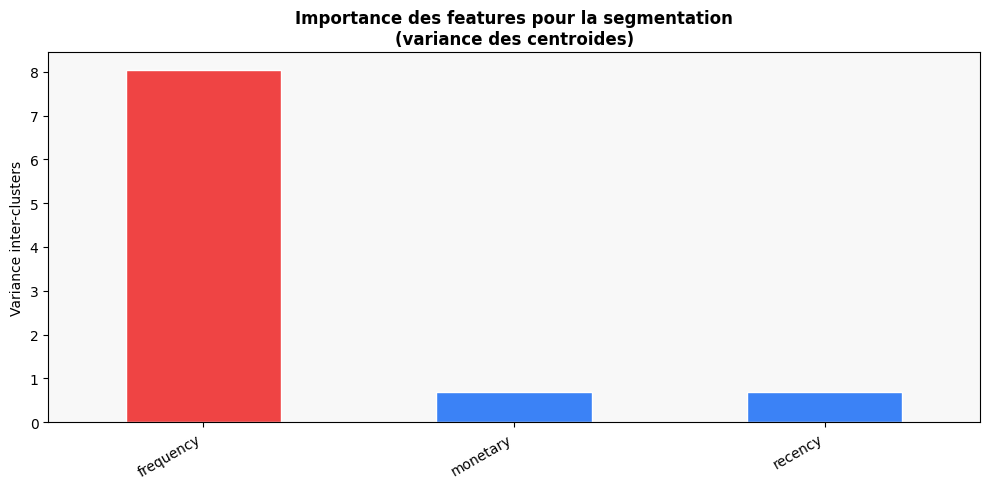

=== IMPORTANCE DES FEATURES ===
  frequency                 : 8.0442
  monetary                  : 0.6996
  recency                   : 0.6829


In [22]:
# ─────────────────────────────────────────────
# CELLULE 21 — Importance des features
# (variance inter-clusters des centroïdes)
# ─────────────────────────────────────────────

centroids_df       = pd.DataFrame(kmeans.cluster_centers_, columns=FEATURES_CLUSTER)
feature_importance = centroids_df.var().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_fi = ['#EF4444' if i == 0 else '#3B82F6' for i in range(len(feature_importance))]
feature_importance.plot(kind='bar', ax=ax, color=colors_fi, edgecolor='white')
ax.set_title('Importance des features pour la segmentation\n(variance des centroides)',
             fontweight='bold')
ax.set_ylabel('Variance inter-clusters')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('feature_importance_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== IMPORTANCE DES FEATURES ===')
for feat, val in feature_importance.items():
    print(f'  {feat:<25} : {val:.4f}')

## 13 — Drill-down : Gros Acheteurs

Les **Gros Acheteurs** représentent une part disproportionnée du CA malgré une fréquence d'achat faible.  
Ce drill-down identifie :

1. Les **catégories de produits** surreprésentées chez ce segment
2. Les **régions brésiliennes (états)** d'où ils proviennent
3. Leur **comportement de paiement** comparé aux autres segments

Ces informations permettent de cibler les campagnes de réachat à J+30, J+60 et J+90.

Gros Acheteurs : 27,855 clients


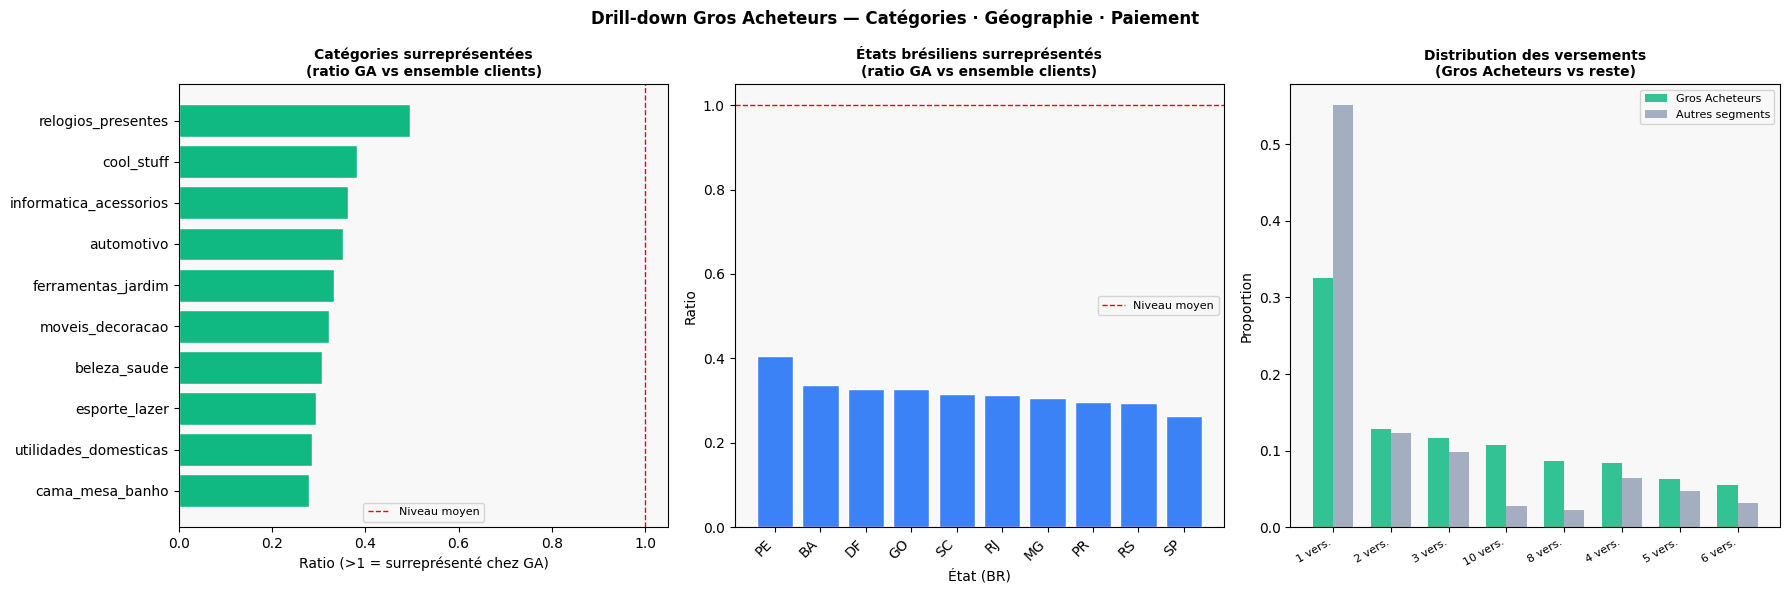


=== RAPPORT GROS ACHETEURS ===
  Nombre de clients  : 27,855
  CA total           : 8,864,265 BRL
  Montant moyen      : 318 BRL
  Récence moyenne    : 173 jours

  Top 5 catégories (ratio GA/ensemble) :
    relogios_presentes                       ratio=0.50
    cool_stuff                               ratio=0.38
    informatica_acessorios                   ratio=0.36
    automotivo                               ratio=0.35
    ferramentas_jardim                       ratio=0.33

  Top 3 états surreprésentés :
    PE ratio=0.41
    BA ratio=0.34
    DF ratio=0.33


In [23]:
# ─────────────────────────────────────────────
# CELLULE 24 — Drill-down Gros Acheteurs
# ─────────────────────────────────────────────

# Identifier les clients "Gros Acheteurs"
ga_ids = rfm[rfm['segment'] == 'Gros Acheteurs']['customer_unique_id']
print(f'Gros Acheteurs : {len(ga_ids):,} clients')

# Fusionner avec la base de données orders pour retrouver les order_ids
ga_orders = base[base['customer_unique_id'].isin(ga_ids)][['customer_unique_id','order_id','revenue']]

# Fusionner avec items pour récupérer les product_ids
ga_items = items[items['order_id'].isin(ga_orders['order_id'])].merge(
    products[['product_id','product_category_name']], on='product_id', how='left'
)

# Fusionner avec customers pour récupérer l'état
ga_customers = rfm[rfm['segment'] == 'Gros Acheteurs'][['customer_unique_id','customer_state']]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── 1. Top catégories produits ─────────────────────────────────────────────
top_cats = (
    ga_items['product_category_name']
    .value_counts()
    .head(10)
)
all_cats = (
    items.merge(products[['product_id','product_category_name']], on='product_id', how='left')
    ['product_category_name'].value_counts()
)
# Ratio Gros Acheteurs vs ensemble
cat_ratio = (top_cats / all_cats).dropna().sort_values(ascending=False).head(10)

axes[0].barh(cat_ratio.index[::-1], cat_ratio.values[::-1], color='#10B981', edgecolor='white')
axes[0].set_title('Catégories surreprésentées\n(ratio GA vs ensemble clients)', fontweight='bold', fontsize=10)
axes[0].set_xlabel('Ratio (>1 = surreprésenté chez GA)')
axes[0].axvline(1.0, color='red', linestyle='--', lw=1, label='Niveau moyen')
axes[0].legend(fontsize=8)

# ── 2. Répartition géographique ────────────────────────────────────────────
top_states = ga_customers['customer_state'].value_counts().head(10)
all_states = rfm['customer_state'].value_counts()
state_ratio = (top_states / all_states).dropna().sort_values(ascending=False).head(10)

axes[1].bar(state_ratio.index, state_ratio.values, color='#3B82F6', edgecolor='white')
axes[1].set_title('États brésiliens surreprésentés\n(ratio GA vs ensemble clients)', fontweight='bold', fontsize=10)
axes[1].set_xlabel('État (BR)')
axes[1].set_ylabel('Ratio')
axes[1].axhline(1.0, color='red', linestyle='--', lw=1, label='Niveau moyen')
axes[1].legend(fontsize=8)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# ── 3. Comportement de paiement ────────────────────────────────────────────
ga_rfm = rfm[rfm['segment'] == 'Gros Acheteurs']
other_rfm = rfm[rfm['segment'] != 'Gros Acheteurs']

pay_ga    = ga_rfm['payment_installments'].value_counts(normalize=True).head(8)
pay_other = other_rfm['payment_installments'].value_counts(normalize=True).reindex(pay_ga.index, fill_value=0)

x = np.arange(len(pay_ga))
w = 0.35
axes[2].bar(x - w/2, pay_ga.values,    width=w, label='Gros Acheteurs', color='#10B981', alpha=0.85)
axes[2].bar(x + w/2, pay_other.values, width=w, label='Autres segments', color='#94A3B8', alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels([f'{int(v)} vers.' for v in pay_ga.index], rotation=30, ha='right', fontsize=8)
axes[2].set_title('Distribution des versements\n(Gros Acheteurs vs reste)', fontweight='bold', fontsize=10)
axes[2].set_ylabel('Proportion')
axes[2].legend(fontsize=8)

plt.suptitle('Drill-down Gros Acheteurs — Catégories · Géographie · Paiement',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('drilldown_gros_acheteurs.png', dpi=150, bbox_inches='tight')
plt.show()

# Rapport texte
print()
print('=== RAPPORT GROS ACHETEURS ===')
print(f'  Nombre de clients  : {len(ga_ids):,}')
print(f'  CA total           : {ga_rfm["monetary"].sum():,.0f} BRL')
print(f'  Montant moyen      : {ga_rfm["monetary"].mean():,.0f} BRL')
print(f'  Récence moyenne    : {ga_rfm["recency"].mean():.0f} jours')
print()
print('  Top 5 catégories (ratio GA/ensemble) :')
for cat, ratio in cat_ratio.head(5).items():
    print(f'    {cat:<40} ratio={ratio:.2f}')
print()
print('  Top 3 états surreprésentés :')
for state, ratio in state_ratio.head(3).items():
    print(f'    {state} ratio={ratio:.2f}')


## 14 — Export du Dataset Segmenté

In [24]:
# ─────────────────────────────────────────────
# CELLULE 22 — Sauvegarde
# ─────────────────────────────────────────────

import os
os.makedirs('./outputs', exist_ok=True)

rfm_export = rfm.drop(columns=['pca1','pca2'], errors='ignore')
rfm_export.to_csv('./outputs/rfm_segments.csv', index=False)

print('Dataset segmente sauvegarde : outputs/rfm_segments.csv')
print(f'   {len(rfm_export):,} clients x {rfm_export.shape[1]} colonnes')
print(f'   Colonnes : {rfm_export.columns.tolist()}')


Dataset segmente sauvegarde : outputs/rfm_segments.csv
   93,358 clients x 11 colonnes
   Colonnes : ['customer_unique_id', 'recency', 'frequency', 'monetary', 'avg_order_value', 'payment_installments', 'preferred_payment', 'customer_state', 'payment_encoded', 'cluster', 'segment']


## 15 — Synthèse Finale

In [25]:
# ─────────────────────────────────────────────
# Synthèse finale
# ─────────────────────────────────────────────

print('=' * 70)
print('   SYNTHÈSE — SEGMENTATION CLIENTS RFM PUR')
print('=' * 70)

print(f'\n-- Normalisation appliquée : {best_scaler_name} --')
print(f'   Features utilisées pour le clustering : {FEATURES_CLUSTER}')
print()
print(f'   {"Feature":<25} | {"Skew":>6} | {"% Outliers":>10} | Gravité')
print(f'   {"-"*65}')
for col, info in outlier_report.items():
    if col in FEATURES_CLUSTER:
        print(f'   {col:<25} | {info["skew"]:>6.2f} | {info["pct_outliers"]:>9.1f}% | {info["gravite"]}')

auto_k_val = list(K_RANGE)[np.argmax(sil_scores)]
print(f'\n-- Algorithme retenu : K-Means 3D RFM pur --')
print(f'   k auto (Silhouette max)  : {auto_k_val}')
print(f'   k retenu (métier+Elbow)  : {best_k}')
print(f'   Silhouette Score (k={best_k}) : {final_sil:.4f}')
print(f'   Inertie                  : {kmeans.inertia_:,.0f}')
print(f'   Variance PCA 2D          : {pca.explained_variance_ratio_.sum()*100:.1f}%  (visualisation partielle)')

print(f'\n-- Segments identifiés --')
for cluster_id, name in segment_names.items():
    row = cluster_profile.loc[cluster_id]
    print(f'   {name:<25} | {row["pct_clients"]:.1f}% clients | {row["pct_ca"]:.1f}% CA'
          f' | recence moy {row["recency_moy"]:.0f}j | montant moy {row["monetary_moy"]:.0f} BRL')

print(f'\n-- Feature la plus discriminante --')
centroids_df_final = pd.DataFrame(kmeans.cluster_centers_, columns=FEATURES_CLUSTER)
fi_final = centroids_df_final.var().sort_values(ascending=False)
for feat, val in fi_final.items():
    print(f'   {feat:<25} : {val:.4f}')
print(f'   -> {fi_final.idxmax()} est la dimension principale')

print(f'\n-- Recommandations marketing --')
for cluster_id, name in segment_names.items():
    row = cluster_profile.loc[cluster_id]
    if name == 'Clients Fideles':
        print(f'\n   Clients Fidèles ({row["pct_clients"]:.1f}% clients | {row["pct_ca"]:.1f}% CA)')
        print(f'     -> Multi-achat confirmé (freq > 2), panier élevé (308 BRL).')
        print(f'        Réactivation : programme fidélité, offre anniversaire.')
        print(f'        Objectif : réduire la récence et relancer l\'engagement.')
    elif name == 'Gros Acheteurs':
        print(f'\n   Gros Acheteurs ({row["pct_clients"]:.1f}% clients | {row["pct_ca"]:.1f}% CA)')
        print(f'     -> PRIORITÉ 1 : 57.5% du CA, mais achat unique.')
        print(f'        Campagne réachat J+30 / J+60 / J+90 avec offre "2e commande".')
        print(f'        Cibles : catégories surreprésentées identifiées dans le drill-down.')
    elif name == 'Nouveaux Acheteurs':
        print(f'\n   Nouveaux Acheteurs ({row["pct_clients"]:.1f}% clients | {row["pct_ca"]:.1f}% CA)')
        print(f'     -> Les plus récents (147j), 1 commande, petit panier (69 BRL).')
        print(f'        Onboarding : email de bienvenue, cross-sell sur catégories accessibles.')
        print(f'        Objectif : déclencher la 2e commande avant 90 jours.')
    elif name == 'Clients Perdus':
        print(f'\n   Clients Perdus ({row["pct_clients"]:.1f}% clients | {row["pct_ca"]:.1f}% CA)')
        print(f'     -> Inactifs depuis 424j en moyenne, faible valeur historique.')
        print(f'        1 campagne dernier recours (coupon fort), puis exclusion des listes actives.')

print(f'\n-- Limites documentées --')
print(f'   1. k=4 est un choix métier (Elbow + granularité CRM).')
print(f'      Le Silhouette seul retournerait k={auto_k_val}.')
print(f'   2. PCA 2D = {pca.explained_variance_ratio_.sum()*100:.1f}% de variance — chevauchements visuels normaux.')
print(f'   3. Sur Olist, 93% des clients ont frequency=1 → Clients Fidèles')
print(f'      reste structurellement petit (3% des clients, freq médiane = 2).')
print(f'   4. payment_installments conservé en descriptif uniquement (radar).')

print(f'\nDataset segmenté sauvegardé : outputs/rfm_segments.csv')


   SYNTHÈSE — SEGMENTATION CLIENTS RFM PUR

-- Normalisation appliquée : Hybride (log1p + StandardScaler) — RFM pur 3 features --
   Features utilisées pour le clustering : ['recency', 'frequency', 'monetary']

   Feature                   |   Skew | % Outliers | Gravité
   -----------------------------------------------------------------
   recency                   |   0.45 |       0.0% | FAIBLE → StandardScaler OK
   frequency                 |  11.10 |       3.0% | ÉLEVÉ  → log1p + StandardScaler
   monetary                  |   9.21 |       7.9% | ÉLEVÉ  → log1p + StandardScaler

-- Algorithme retenu : K-Means 3D RFM pur --
   k auto (Silhouette max)  : 2
   k retenu (métier+Elbow)  : 4
   Silhouette Score (k=4) : 0.3693
   Inertie                  : 85,766
   Variance PCA 2D          : 72.2%  (visualisation partielle)

-- Segments identifiés --
   Clients Fideles           | 3.0% clients | 5.6% CA | recence moy 219j | montant moy 309 BRL
   Gros Acheteurs            | 29.8% clien